In [66]:
# import os
# import sys
# from pathlib import Path
# import shutil
# import datetime
# import math

# import attrs
# from liblaf import cherries
# from loguru import logger
# from tqdm import tqdm

# # 替换此行
# # sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__), "../../src")))

# # 方法1：使用当前工作目录
# notebook_dir = os.getcwd()  # 获取当前工作目录
# src_path = os.path.abspath(os.path.join(notebook_dir, "../../src"))
# sys.path.insert(0, src_path)


# import qoc 
# import qoc.api as api # pyright: ignore


# db: str = qoc.data_dir("database").as_uri().replace("file://", "lmdb://")


# online: bool = False
# symbols: list[str] = ["XRPUSDT","BTCUSDT", "ETHUSDT", "LTCUSDT", "ADAUSDT", "SOLUSDT", "BNBUSDT", "LINKUSDT",
#             "DOGEUSDT", "SHIBUSDT", "PEPEUSDT", "PENGUUSDT","BONKUSDT", "TRUMPUSDT", "SPXUSDT", "FLOKIUSDT", "WIFUSDT"]



# # symbols: list[str] = ["BTCUSDT", "DOGEUSDT"]    
# transaction_fee: float = 0.01  # 交易费用为0.1%
# interval: str = "5m"
# start_date: str = "2024-01-01"
# end_date: str = "2025-08-31"
# output_dir: str = "5m_klines_raw"


# offline_db_path = Path("union")
# if offline_db_path.exists():
#     # logger.info(f"删除现有数据库文件夹: {offline_db_path}")
#     shutil.rmtree(offline_db_path)



# from offline_fetch import fetch_for_offline
# import arcticdb as adb
# uri = "lmdb://union"

# ac = adb.Arctic(uri)

# qoc_library = ac.get_library('market', create_if_missing=True)

# fetch_for_offline(symbols, interval, start_date, end_date, output_dir, qoc_library)


In [67]:
import pandas as pd

btc = pd.read_csv("5m_klines_raw/BTCUSDT_klines_5m.csv")
doge = pd.read_csv("5m_klines_raw/DOGEUSDT_klines_5m.csv")
pepe = pd.read_csv("5m_klines_raw/PEPEUSDT_klines_5m.csv")
for df in [btc, doge, pepe]:
    df['Close Time'] = df['Close Time'].apply(lambda x: x * 1000+999 if x < 2000000000000 else x)
    df['Open Time'] = df['Open Time'].apply(lambda x: x * 1000 if x < 2000000000000 else x)
    df['Open Time'] = pd.to_datetime(df['Open Time'], unit='us')
    df['Close Time'] = pd.to_datetime(df['Close Time'], unit='us')

In [68]:
period = ['2024-01-01', '2026-01-01']
btc = btc.set_index('Open Time').loc[period[0]:period[1]]
doge = doge.set_index('Open Time').loc[period[0]:period[1]]
pepe = pepe.set_index('Open Time').loc[period[0]:period[1]]

In [69]:
btc

,Close Time,index,Open,High,Low,Close,Volume,Quote Asset Volume,Number of Trades,Taker Buy Base Volume,Taker Buy Quote Volume,Ignore
Open Time,,,,,,,,,,,,
2024-01-01 00:00:00,2024-01-01 00:04:59.999999,0,42283.58,42397.23,42261.02,42397.23,155.25731,6.572926e+06,6350,106.05732,4.490262e+06,0
2024-01-01 00:05:00,2024-01-01 00:09:59.999999,1,42397.22,42432.74,42385.26,42409.96,141.31102,5.993375e+06,5134,69.45156,2.945452e+06,0
2024-01-01 00:10:00,2024-01-01 00:14:59.999999,2,42409.97,42488.09,42409.96,42488.00,135.14249,5.738386e+06,5167,73.25966,3.110338e+06,0
2024-01-01 00:15:00,2024-01-01 00:19:59.999999,3,42488.00,42554.57,42458.58,42458.85,163.32541,6.943230e+06,6153,82.81591,3.520689e+06,0
2024-01-01 00:20:00,2024-01-01 00:24:59.999999,4,42458.85,42491.10,42445.84,42473.93,117.27112,4.979136e+06,3094,49.06278,2.083183e+06,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-31 23:35:00,2025-08-31 23:39:59.999999,175387,108251.22,108416.35,108111.00,108156.01,113.69077,1.230942e+07,16780,65.43264,7.086852e+06,0
2025-08-31 23:40:00,2025-08-31 23:44:59.999999,175388,108156.00,108258.00,108076.93,108258.00,102.71622,1.110862e+07,13502,56.70324,6.131969e+06,0
2025-08-31 23:45:00,2025-08-31 23:49:59.999999,175389,108257.99,108356.05,108194.86,108283.23,86.46452,9.361689e+06,12602,53.26288,5.766744e+06,0


# rev-strat

Calculating past growth...
Parameters:
PAST_WINDOW: 60, HOLDING_PERIOD: 360, THRESHOLD: -0.02, INITIAL: 200, MAX_HOLD: 5, FEE: 0.0005, BULLET_SIZE: 20


Processing: 100%|██████████| 175392/175392 [00:00<00:00, 755371.63it/s]


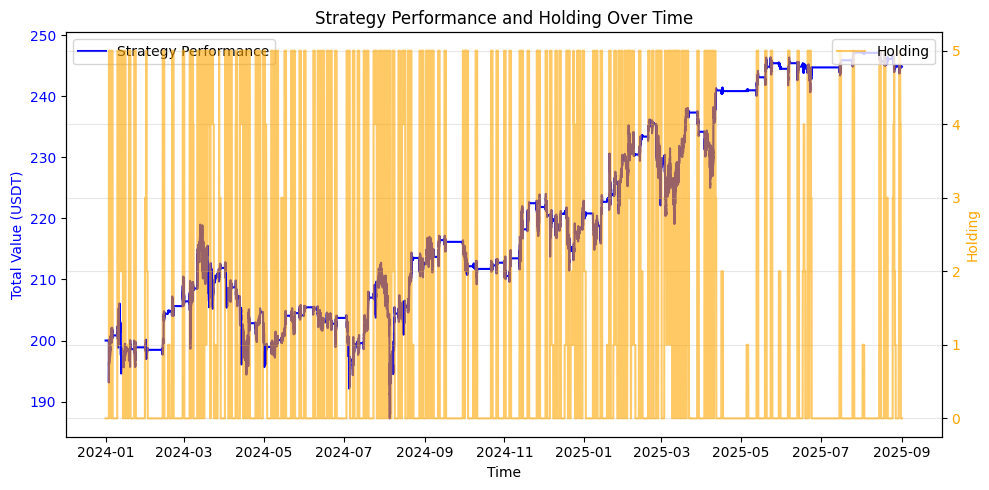

In [70]:
import numpy as np
import pandas as pd
from collections import deque
from tqdm import tqdm


# Set the parameters
# btc = btc.loc['2024-01-01':'2024-07-01']
PAST_WINDOW = 60     # 5 hours with 5-minute intervals
HOLDING_PERIOD = 360     # 17.5 hours ahead
THRESHOLD = -0.02
MAX_HOLD = 5
BULLET_SIZE = 20
INITIAL = 200
FEE = 0.0005


print("Calculating past growth...")
def rev_strategy(
    btc: pd.DataFrame,
    past_window: int ,
    holding_period: int,
    threshold: float = 0.01,
    initial_cap: float = 100000,
    trade_size: float = 1000,
    fee: float = 0.001,
    max_hold: int = 5
):
    """
    更稳健的策略实现：存储订单历史，到期自动清仓

    Parameters
    ----------
    btc : pd.DataFrame
        带有 'Close' 列的BTC价格数据
    past_growth, future_growth : pd.Series
        历史与未来涨幅
    holding_period : int
        持仓期(单位与btc的时间索引一致)
    threshold : float
        买入阈值
    initial_cap : float
        初始资金
    trade_size : float
        每次交易的USDT金额
    fee : float
        单边手续费比例
    max_hold : int
        最大持仓单数
    """

    prices = btc["Close"].values
    n = len(prices)

    # 预分配结果
    total_value = np.zeros(n)
    holdings_array = np.zeros(n)
    pnl_records = np.zeros(n)  # 每次平仓的收益率记录

    # 策略状态
    capital = initial_cap     # USDT
    amount = 0.0              # 持仓BTC数量
    open_orders = deque()     # 存储未平仓订单 [{time, price, qty}]
    now_holding = 0

    for t in tqdm(range(n), desc="Processing"):
        
        price_t = prices[t]
        total_value[t] = capital + amount * price_t
        holdings_array[t] = now_holding
        past_growth = 0.0

        if t >= past_window:
            past_growth = (price_t - prices[t - past_window]) / prices[t - past_window]
        # print(f"Time: {t}, Price: {price_t}, Past Growth: {past_growth if t >= past_window else 'N/A'}, Holdings: {now_holding}, Capital: {capital}, Amount: {amount}")


        # --- 买入信号 ---
        if (
            t >= 1 and past_growth is not None
            and past_growth < threshold
            and now_holding < max_hold
        ):
            qty = trade_size / price_t
            cost = trade_size * (1 + fee)

            if capital >= cost:  # 资金充足才买
                capital -= cost
                amount += qty
                now_holding += 1
                open_orders.append({"time": t, "price": price_t, "qty": qty})

        # --- 到期清仓 ---
        while open_orders and (t - open_orders[0]["time"]) >= holding_period:
            order = open_orders.popleft()
            sell_qty = order["qty"]
            sell_revenue = sell_qty * price_t * (1 - fee)

            capital += sell_revenue
            amount -= sell_qty
            now_holding -= 1

            pnl = ((price_t - order["price"]) - (order["price"] + price_t) * fee)/order["price"]
            pnl_records[t] = pnl

    # 生成结果
    performance_df = pd.DataFrame(
        {"Total Value": total_value}, index=btc.index
    )
    holding_series = pd.Series(holdings_array, index=btc.index)
    pnl_series = pd.Series(pnl_records, index=btc.index)
    return performance_df, pnl_series, holding_series

print("Parameters:")
print(f"PAST_WINDOW: {PAST_WINDOW}, HOLDING_PERIOD: {HOLDING_PERIOD}, THRESHOLD: {THRESHOLD}, INITIAL: {INITIAL}, MAX_HOLD: {MAX_HOLD}, FEE: {FEE}, BULLET_SIZE: {BULLET_SIZE}")
# 运行优化后的策略
strategy_performance, pnls, holding = rev_strategy(
    btc, past_window=PAST_WINDOW ,holding_period=HOLDING_PERIOD, threshold=THRESHOLD, initial_cap=INITIAL, max_hold=MAX_HOLD, fee=FEE, trade_size=BULLET_SIZE
)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
ax1 = plt.gca()
ax2 = ax1.twinx()


x = [i * 5 for i in range(len(strategy_performance))]  # 每一行对应的分钟数



# 策略表现
ax1.plot(holding.index, strategy_performance['Total Value'], label='Strategy Performance', color='blue')
ax1.set_ylabel('Total Value (USDT)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# 持仓
ax2.plot(holding.index, holding.values, label='Holding', color='orange', alpha=0.6)
ax2.set_ylabel('Holding', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Strategy Performance and Holding Over Time')
ax1.set_xlabel('Time')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [71]:
# 筛选出 pnls 不等于 0 的值
non_zero_pnls = pnls[pnls != 0]

# 将 pnls 转换为 numpy 数组以便计算
import numpy as np
pnls_array = np.array(non_zero_pnls)

# 计算基本统计指标
stats = {
    "总交易次数": len(pnls_array),
    "平均收益率": np.mean(pnls_array),
    "中位数收益率": np.median(pnls_array),
    "最大收益率": np.max(pnls_array),
    "最小收益率": np.min(pnls_array),
    "标准差": np.std(pnls_array),
    "正收益交易数": np.sum(pnls_array > 0),
    "负收益交易数": np.sum(pnls_array < 0),
    "胜率": np.mean(pnls_array > 0),
    "盈亏比": np.mean(pnls_array[pnls_array > 0]) / abs(np.mean(pnls_array[pnls_array < 0])) if np.any(pnls_array < 0) else float('inf'),
    "夏普比率": np.mean(pnls_array) / np.std(pnls_array) if np.std(pnls_array) > 0 else 0,
    "总收益率": np.sum(pnls_array)
}

# 打印统计指标
for key, value in stats.items():
    print(f"{key}: {value:.4f}" if isinstance(value, (float, np.float64)) else f"{key}: {value}")

总交易次数: 767
平均收益率: 0.0029
中位数收益率: 0.0045
最大收益率: 0.1159
最小收益率: -0.1031
标准差: 0.0310
正收益交易数: 445
负收益交易数: 322
胜率: 0.5802
盈亏比: 0.9290
夏普比率: 0.0944
总收益率: 2.2424


In [72]:
strategy_performance_1 = strategy_performance.copy()

In [73]:
unit_returns = strategy_performance['Total Value'].pct_change().dropna()
mean_return = unit_returns.mean()
std_return = unit_returns.std()
sharpe_ratio = mean_return / std_return

In [74]:
sharpe_ratio

0.002498283392370254

# trend_strat

In [75]:
DERI_WINDOW = 1    # 2d


n=int(12*24*DERI_WINDOW)  # VWAP window in 5m
# threshold = 750    # $/d


/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_10544/3173866817.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pos_arr = btc["pos"].fillna(False).values
/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_10544/3173866817.py:58: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  neg_arr = btc["neg"].fillna(False).values
Processing: 100%|██████████| 175392/175392 [00:01<00:00, 158945.45it/s]


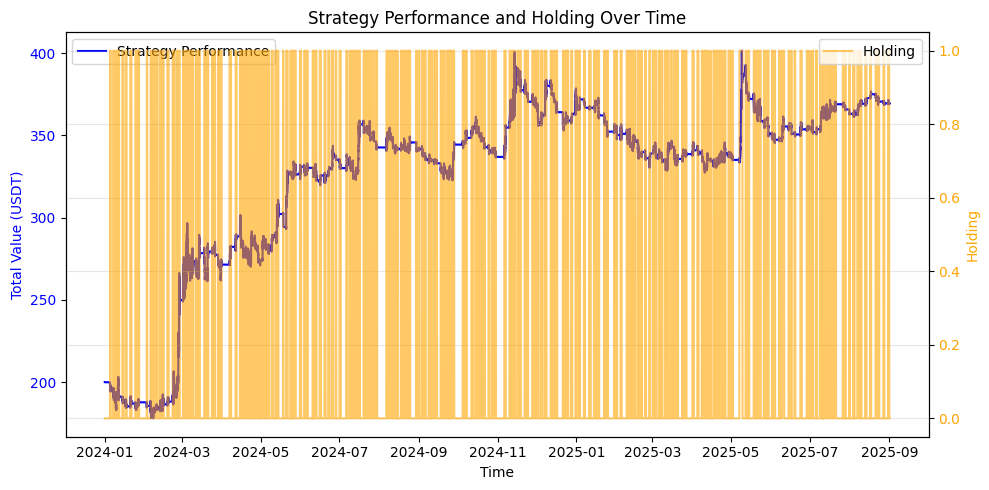

总交易次数: 231
平均收益率: 0.0084
中位数收益率: -0.0028
最大收益率: 0.5165
最小收益率: -0.1508
标准差: 0.0781
正收益交易数: 110
负收益交易数: 121
胜率: 0.4762
盈亏比: 1.5895
夏普比率: 0.1075
总收益率: 1.9382


In [76]:
import numpy as np
import pandas as pd
from collections import deque
from tqdm import tqdm

import numpy as np
import pandas as pd
from collections import deque
from tqdm import tqdm

def trend_strategy(
    df: pd.DataFrame,
    vwap_n: int,
    trade_size: float,
    initial_cap: float = 200.0,
    fee: float = 0.0005,
):
    btc = df.copy()
    n = len(btc)

    # ===== 1. 指标计算（仅用历史数据） =====
    cum_vol    = btc["Volume"].rolling(window=vwap_n, min_periods=vwap_n).sum()
    cum_vol_px = (btc["Close"] * btc["Volume"]).rolling(window=vwap_n, min_periods=vwap_n).sum()
    btc["VWAP"] = cum_vol_px / cum_vol

    # import matplotlib.pyplot as plt
    # plt.figure(figsize=(12, 6))
    # plt.plot(btc.index, btc['Close'], label='Close Price', alpha=0.5)
    # plt.plot(btc.index, btc['VWAP'], label='VWAP', color='orange', alpha=0.7)
    # plt.title('Close Price and VWAP Over Time')
    # plt.xlabel('Time')
    # plt.ylabel('Price')
    # plt.legend()
    # plt.grid(alpha=0.3)
    # plt.tight_layout()
    # plt.show()
    # plt.close()

    # 只使用过去数据，差分与过去值比较
    btc["VWAP_derivative"]  = (btc["VWAP"] - btc["VWAP"].shift(vwap_n)) / vwap_n
    btc["VWAP_derivative2"] = (btc["VWAP_derivative"] - btc["VWAP_derivative"].shift(vwap_n)) / vwap_n
    btc["VWAP_derivative3"] = (btc["VWAP_derivative2"] - btc["VWAP_derivative2"].shift(vwap_n)) / vwap_n

    # 信号滞后1步，确保t时刻只用t-1及更早数据
    btc["pos"] = (
        (btc["VWAP_derivative"]  > 0) &
        (btc["VWAP_derivative2"] > 0) &
        (btc["VWAP_derivative3"] > 0)
    ).shift(1)
    btc["neg"] = (
        (btc["VWAP_derivative"]  < 0) &
        (btc["VWAP_derivative2"] < 0) &
        (btc["VWAP_derivative3"] < 0)
    ).shift(1)

    prices = btc["Close"].values
    pos_arr = btc["pos"].fillna(False).values
    neg_arr = btc["neg"].fillna(False).values

    # ===== 2. 结果容器 =====
    total_value = np.zeros(n)
    holdings_array = np.zeros(n)
    pnl_records = np.zeros(n)

    # ===== 3. 策略状态 =====
    capital = initial_cap
    amount = 0.0
    open_orders = deque()
    now_holding = 0

    # ===== 4. 交易循环 =====
    for t in tqdm(range(n), desc="Processing"):
        price_t = prices[t]
        total_value[t] = capital + amount * price_t
        holdings_array[t] = now_holding

        # --- 买入信号 ---
        if (
            t >= 1 and btc['pos'].iloc[t-1]
            and now_holding==0
        ):
            qty = trade_size / price_t
            cost = trade_size * (1 + fee)

            if capital >= cost:  # 资金充足才买
                capital -= cost
                amount += qty
                now_holding += 1
                open_orders.append({"time": t, "price": price_t, "qty": qty})

        if not btc['pos'].iloc[t] and now_holding > 0:
            # 平多仓
            while open_orders and now_holding > 0:
                order = open_orders.popleft()
                sell_qty = order["qty"]
                sell_price = price_t
                proceeds = sell_qty * sell_price * (1 - fee)
                capital += proceeds
                amount -= sell_qty
                now_holding -= 1

                # 计算并记录收益率
                entry_price = order["price"]
                pnl = (sell_price - entry_price) / entry_price
                pnl_records[t] += pnl

    # ===== 5. 结果整理 =====
    performance_df = pd.DataFrame({
        "Total Value": total_value
    }, index=btc.index)

    pnl_series = pd.Series(pnl_records, index=btc.index, name="PnL")
    holding_series = pd.Series(holdings_array, index=btc.index, name="Holding")

    # ===== 6. 固定返回格式 =====
    return performance_df, pnl_series, holding_series



# 运行优化后的策略
strategy_performance, pnls, holding = trend_strategy(
    pepe,
    vwap_n=n,
    trade_size=100,
    initial_cap=200,
)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
ax1 = plt.gca()
ax2 = ax1.twinx()


x = [i * 5 for i in range(len(strategy_performance))]  # 每一行对应的分钟数



# 策略表现
ax1.plot(strategy_performance.index, strategy_performance['Total Value'], label='Strategy Performance', color='blue')
ax1.set_ylabel('Total Value (USDT)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# 持仓
ax2.plot(strategy_performance.index, holding.values, label='Holding', color='orange', alpha=0.6)
ax2.set_ylabel('Holding', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Strategy Performance and Holding Over Time')
ax1.set_xlabel('Time')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 筛选出 pnls 不等于 0 的值
non_zero_pnls = pnls[pnls != 0]

# 将 pnls 转换为 numpy 数组以便计算
import numpy as np
pnls_array = np.array(non_zero_pnls)

# 计算基本统计指标
stats = {
    "总交易次数": len(pnls_array),
    "平均收益率": np.mean(pnls_array),
    "中位数收益率": np.median(pnls_array),
    "最大收益率": np.max(pnls_array),
    "最小收益率": np.min(pnls_array),
    "标准差": np.std(pnls_array),
    "正收益交易数": np.sum(pnls_array > 0),
    "负收益交易数": np.sum(pnls_array < 0),
    "胜率": np.mean(pnls_array > 0),
    "盈亏比": np.mean(pnls_array[pnls_array > 0]) / abs(np.mean(pnls_array[pnls_array < 0])) if np.any(pnls_array < 0) else float('inf'),
    "夏普比率": np.mean(pnls_array) / np.std(pnls_array) if np.std(pnls_array) > 0 else 0,
    "总收益率": np.sum(pnls_array)
}

# 打印统计指标
for key, value in stats.items():
    print(f"{key}: {value:.4f}" if isinstance(value, (float, np.float64)) else f"{key}: {value}")

strategy_performance_2 = strategy_performance.copy()

/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_10544/3173866817.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pos_arr = btc["pos"].fillna(False).values
/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_10544/3173866817.py:58: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  neg_arr = btc["neg"].fillna(False).values
Processing: 100%|██████████| 175392/175392 [00:01<00:00, 163132.62it/s]


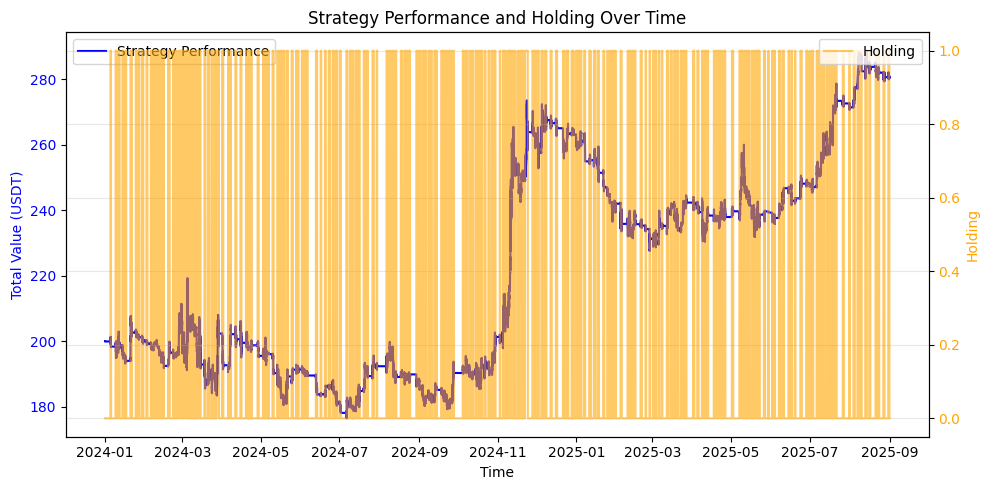

总交易次数: 221
平均收益率: 0.0047
中位数收益率: -0.0033
最大收益率: 0.4307
最小收益率: -0.0958
标准差: 0.0479
正收益交易数: 97
负收益交易数: 124
胜率: 0.4389
盈亏比: 1.7826
夏普比率: 0.0975
总收益率: 1.0313


In [77]:


# 运行优化后的策略
strategy_performance, pnls, holding = trend_strategy(
    doge,
    vwap_n=n,
    trade_size=100,
    initial_cap=200,
)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
ax1 = plt.gca()
ax2 = ax1.twinx()


x = [i * 5 for i in range(len(strategy_performance))]  # 每一行对应的分钟数



# 策略表现
ax1.plot(strategy_performance.index, strategy_performance['Total Value'], label='Strategy Performance', color='blue')
ax1.set_ylabel('Total Value (USDT)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# 持仓
ax2.plot(strategy_performance.index, holding.values, label='Holding', color='orange', alpha=0.6)
ax2.set_ylabel('Holding', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Strategy Performance and Holding Over Time')
ax1.set_xlabel('Time')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 筛选出 pnls 不等于 0 的值
non_zero_pnls = pnls[pnls != 0]

# 将 pnls 转换为 numpy 数组以便计算
import numpy as np
pnls_array = np.array(non_zero_pnls)

# 计算基本统计指标
stats = {
    "总交易次数": len(pnls_array),
    "平均收益率": np.mean(pnls_array),
    "中位数收益率": np.median(pnls_array),
    "最大收益率": np.max(pnls_array),
    "最小收益率": np.min(pnls_array),
    "标准差": np.std(pnls_array),
    "正收益交易数": np.sum(pnls_array > 0),
    "负收益交易数": np.sum(pnls_array < 0),
    "胜率": np.mean(pnls_array > 0),
    "盈亏比": np.mean(pnls_array[pnls_array > 0]) / abs(np.mean(pnls_array[pnls_array < 0])) if np.any(pnls_array < 0) else float('inf'),
    "夏普比率": np.mean(pnls_array) / np.std(pnls_array) if np.std(pnls_array) > 0 else 0,
    "总收益率": np.sum(pnls_array)
}

# 打印统计指标
for key, value in stats.items():
    print(f"{key}: {value:.4f}" if isinstance(value, (float, np.float64)) else f"{key}: {value}")

strategy_performance_3 = strategy_performance.copy()

# tz-strategy

Processing: 100%|██████████| 175392/175392 [00:01<00:00, 105860.93it/s]


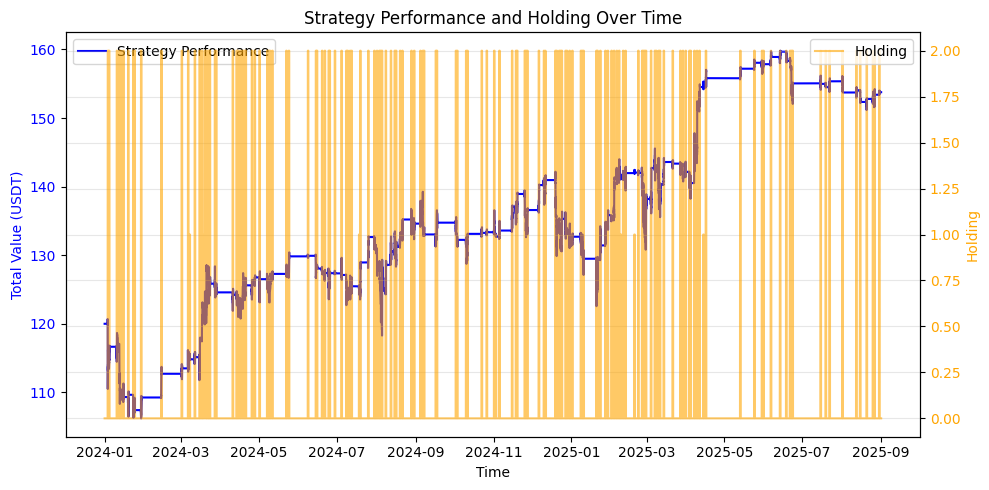

总交易次数: 312
平均收益率: 0.0032
中位数收益率: 0.0014
最大收益率: 0.0670
最小收益率: -0.0682
标准差: 0.0238
正收益交易数: 165
负收益交易数: 147
胜率: 0.5288
盈亏比: 1.2776
夏普比率: 0.1328
总收益率: 0.9879


In [78]:
import numpy as np
import pandas as pd
from collections import deque
from tqdm import tqdm

def implement_strategy(
    btc: pd.DataFrame,
    trade_size: float=1000.0,
    initial_cap: float = 10000.0,
    fee: float = 0.0005,
    threshold: float = -0.02,
    max_holding: int = 24,

):

    prices = btc["Close"].values
    n = len(prices)

    # 预分配结果
    total_value = np.zeros(n)
    holdings_array = np.zeros(n)
    pnl_records = np.zeros(n)  # 每次平仓的收益率记录

    # 策略状态
    capital = initial_cap     # USDT
    amount = 0.0              # 持仓BTC数量
    open_orders = deque()     # 存储未平仓订单 [{time, price, qty}]
    now_holding = 0

    btc['Hour'] = btc.index.hour


    for t in tqdm(range(n), desc="Processing"):
        price_t = prices[t]
        total_value[t] = capital + amount * price_t
        holdings_array[t] = now_holding

        # --- 买入信号 ---
        if (
            t >= 288 
            and (btc['Close'].iloc[t-144]-btc['Close'].iloc[t-288])/btc['Close'].iloc[t-288]<threshold
            and now_holding<max_holding
            and btc['Hour'].iloc[t] in [7,8,9,10,11,12,13]  # 只能在0点、8点、16点买
        ):
            qty = trade_size / price_t
            cost = trade_size * (1 + fee)

            if capital >= cost:  # 资金充足才买
                capital -= cost
                amount += qty
                now_holding += 1
                open_orders.append({"time": t, "price": price_t, "qty": qty})
             
        if now_holding > 0:
            # 平多仓
            while open_orders and open_orders[0]["time"] <= t - 144:
                order = open_orders.popleft()
                sell_qty = order["qty"]
                sell_price = price_t
                proceeds = sell_qty * sell_price * (1 - fee)
                capital += proceeds
                amount -= sell_qty
                now_holding -= 1

                # 计算并记录收益率
                entry_price = order["price"]
                pnl = (sell_price - entry_price) / entry_price
                pnl_records[t] += pnl
       
    # 生成结果
    performance_df = pd.DataFrame(
        {"Total Value": total_value}, index=btc.index
    )
    holding_series = pd.Series(holdings_array, index=btc.index)
    pnl_series = pd.Series(pnl_records, index=btc.index)
    return performance_df, pnl_series, holding_series


# 运行优化后的策略
strategy_performance, pnls, holding = implement_strategy(
    btc,
    trade_size=50.0,
    initial_cap=120.0,
    fee=0.0005,
    threshold=-0.02,
    max_holding=2,
)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
ax1 = plt.gca()
ax2 = ax1.twinx()





# 策略表现
ax1.plot(strategy_performance.index, strategy_performance['Total Value'], label='Strategy Performance', color='blue')
ax1.set_ylabel('Total Value (USDT)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# 持仓
ax2.plot(strategy_performance.index, holding.values, label='Holding', color='orange', alpha=0.6)
ax2.set_ylabel('Holding', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Strategy Performance and Holding Over Time')
ax1.set_xlabel('Time')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 筛选出 pnls 不等于 0 的值
non_zero_pnls = pnls[pnls != 0]

# 将 pnls 转换为 numpy 数组以便计算
import numpy as np
pnls_array = np.array(non_zero_pnls)

# 计算基本统计指标
stats = {
    "总交易次数": len(pnls_array),
    "平均收益率": np.mean(pnls_array),
    "中位数收益率": np.median(pnls_array),
    "最大收益率": np.max(pnls_array),
    "最小收益率": np.min(pnls_array),
    "标准差": np.std(pnls_array),
    "正收益交易数": np.sum(pnls_array > 0),
    "负收益交易数": np.sum(pnls_array < 0),
    "胜率": np.mean(pnls_array > 0),
    "盈亏比": np.mean(pnls_array[pnls_array > 0]) / abs(np.mean(pnls_array[pnls_array < 0])) if np.any(pnls_array < 0) else float('inf'),
    "夏普比率": np.mean(pnls_array) / np.std(pnls_array) if np.std(pnls_array) > 0 else 0,
    "总收益率": np.sum(pnls_array)
}

# 打印统计指标
for key, value in stats.items():
    print(f"{key}: {value:.4f}" if isinstance(value, (float, np.float64)) else f"{key}: {value}")

strategy_performance_4 = strategy_performance.copy()

In [79]:
def sharpe_ratio(strategy_performance) -> float:
    unit_returns = strategy_performance['Total Value'].pct_change().dropna()
    mean_return = unit_returns.mean()
    std_return = unit_returns.std()
    sharpe_ratio = mean_return / std_return
    return sharpe_ratio

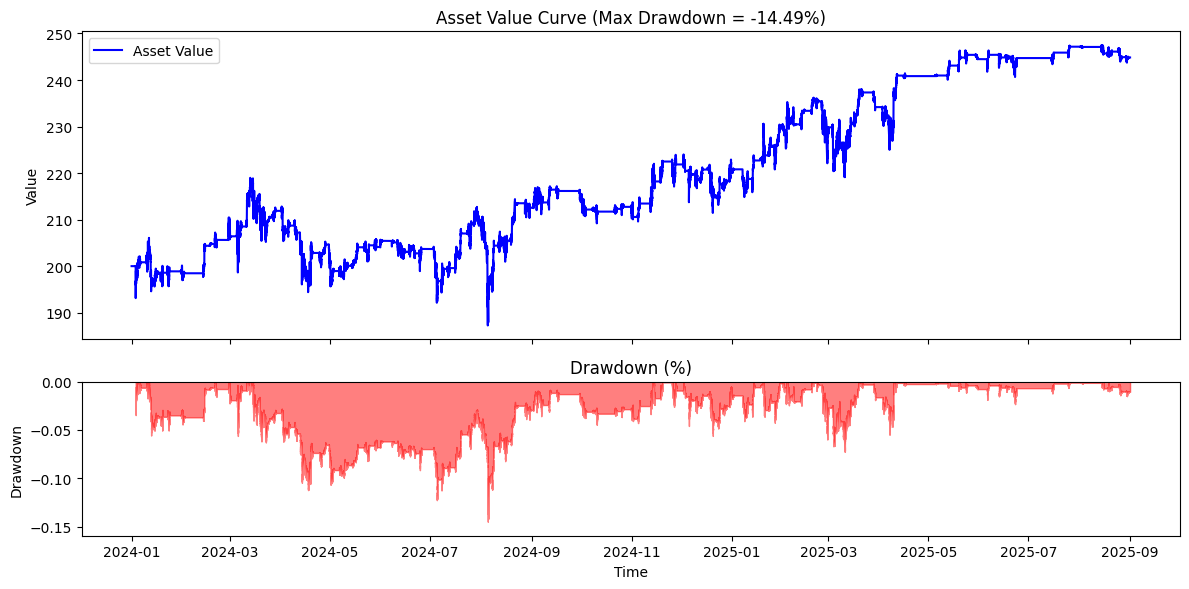

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def calculate_max_drawdown(value_series: pd.Series):
    """
    计算最大回撤百分比
    参数:
        value_series: pd.Series，资产净值或累计收益序列
    返回:
        max_dd: float，最大回撤百分比（如 -0.25 表示 -25%）
        drawdown: pd.Series，每个时间点的回撤
    """
    # 计算历史最高值
    rolling_max = value_series.cummax()
    # 回撤序列
    drawdown = (value_series - rolling_max) / rolling_max
    # 最大回撤
    max_dd = drawdown.min()
    return max_dd, drawdown

# ===== 示例使用 =====
# 假设 performance_df["Total Value"] 是资产序列
def plot_drawdown(performance_df: pd.DataFrame, col="Total Value"):
    series = performance_df[col]

    max_dd, drawdown = calculate_max_drawdown(series)

    fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                           gridspec_kw={"height_ratios":[2,1]})

    # 资产净值曲线
    ax[0].plot(series.index, series, label="Asset Value", color="blue")
    ax[0].set_ylabel("Value")
    ax[0].set_title(f"Asset Value Curve (Max Drawdown = {max_dd:.2%})")
    ax[0].legend(loc="upper left")

    # 回撤曲线
    ax[1].fill_between(drawdown.index, drawdown, 0, color="red", alpha=0.5)
    ax[1].set_ylabel("Drawdown")
    ax[1].set_xlabel("Time")
    ax[1].set_title("Drawdown (%)")
    ax[1].set_ylim(drawdown.min()*1.1, 0)

    plt.tight_layout()
    plt.show()

    return max_dd, drawdown

# 用法:
max_dd, drawdown = plot_drawdown(strategy_performance_1, col="Total Value")


In [81]:
max_dd

-0.14489237334770064

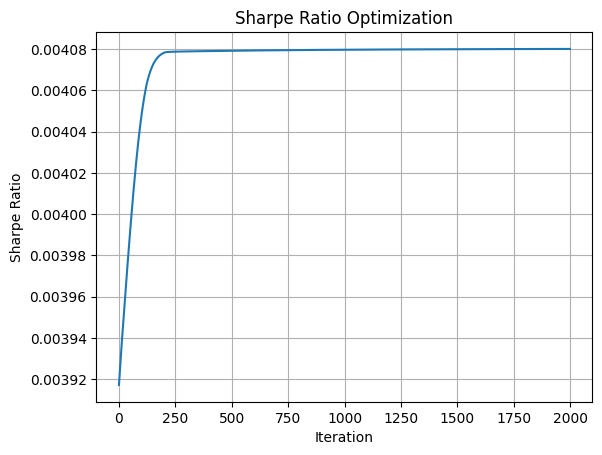

In [82]:
def gradient_ascent(sp_1, sp_2, sp_3, sp_4, learning_rate=0.001, iterations=1000):
    a = 1
    b = 1
    c = 1
    loss_his = []
    def objective(a, b, c):
        combined_sp = 1 * sp_1 + a * sp_2 + b * sp_3 +c * sp_4
        sr = sharpe_ratio(combined_sp)
        dd, _ = calculate_max_drawdown(combined_sp['Total Value'])

        score = sr * (1 + dd)  # 惩罚回撤
        return score
    for _ in range(iterations):
        current_value = objective(a, b, c)
        delta = 1e-2
        grad_a = (objective(a + delta, b, c) - current_value) / delta
        grad_b = (objective(a, b + delta, c) - current_value) / delta
        grad_c = (objective(a, b, c + delta) - current_value) / delta
        a += learning_rate * grad_a
        b += learning_rate * grad_b
        c += learning_rate * grad_c
        loss_his.append(current_value)
    return a, b, c, loss_his
a_opt, b_opt, c_opt, loss_his = gradient_ascent(strategy_performance_1, strategy_performance_2, strategy_performance_3, strategy_performance_4, learning_rate=20, iterations=2000)
plt.plot(loss_his)
plt.xlabel('Iteration')
plt.ylabel('Sharpe Ratio')
plt.title('Sharpe Ratio Optimization')
plt.grid()
plt.show()


In [83]:
a_opt, b_opt, c_opt

(0.7065497627750615, 0.43565353180731053, 1.5278177136571667)

In [89]:
strategy_performance = strategy_performance_1+0.4*strategy_performance_2+0.4*strategy_performance_3+1*strategy_performance_4

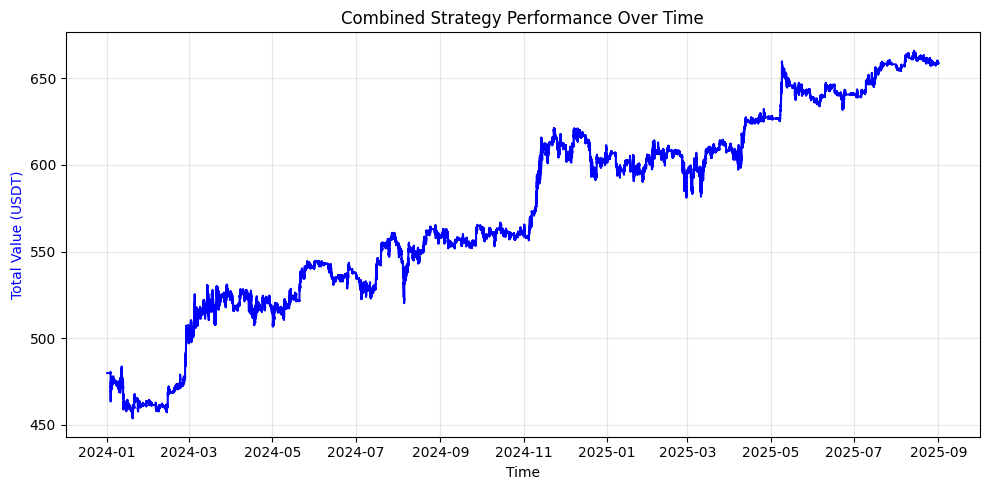

In [90]:
plt.figure(figsize=(10, 5))
plt.plot(strategy_performance.index, strategy_performance['Total Value'], label='Combined Strategy Performance', color='blue')
plt.xlabel('Time')
plt.ylabel('Total Value (USDT)', color='blue')
plt.title('Combined Strategy Performance Over Time')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

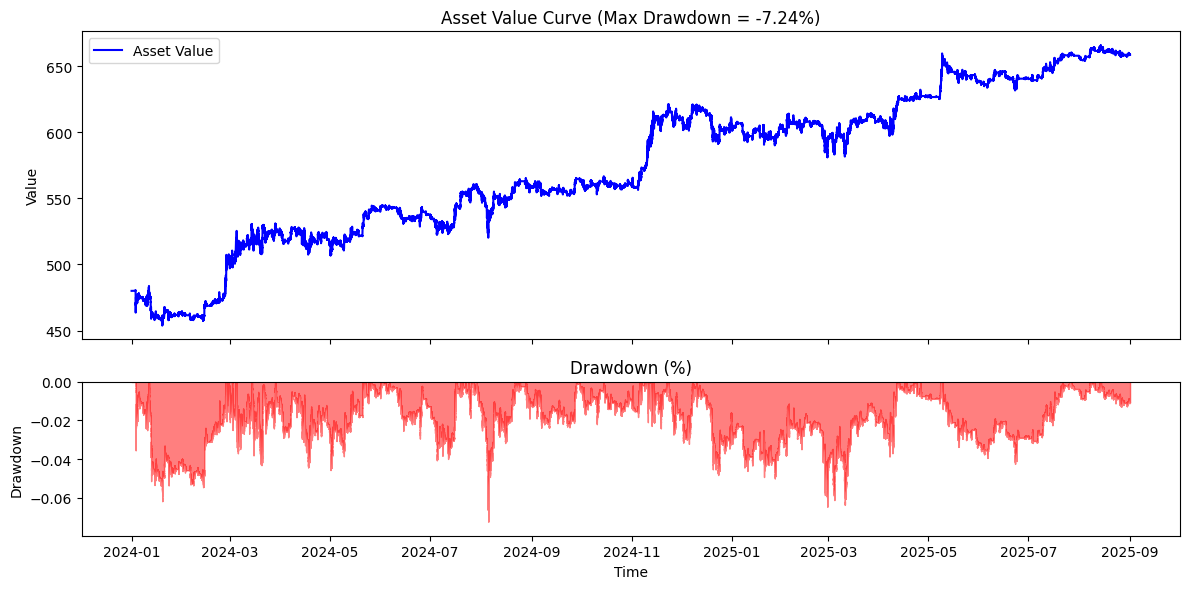

(-0.07238548010279215,
 Open Time
 2024-01-01 00:00:00    0.000000
 2024-01-01 00:05:00    0.000000
 2024-01-01 00:10:00   -0.000167
 2024-01-01 00:15:00   -0.000167
 2024-01-01 00:20:00   -0.000167
                          ...   
 2025-08-31 23:35:00   -0.010794
 2025-08-31 23:40:00   -0.010794
 2025-08-31 23:45:00   -0.010794
 2025-08-31 23:50:00   -0.010794
 2025-08-31 23:55:00   -0.010794
 Name: Total Value, Length: 175392, dtype: float64)

In [91]:
plot_drawdown(strategy_performance, col="Total Value")

In [92]:
sharpe_ratio(strategy_performance)*np.sqrt(12*24*365)

1.3912719668830167

In [93]:
# 按月分组
monthly_groups = strategy_performance.resample('M')

# 初始化结果存储
monthly_results = []
# 遍历每个月的数据
for month, group in monthly_groups:
  if not group.empty:
    # 计算 Sharpe Ratio 和 Max Drawdown
    sr = sharpe_ratio(group) * np.sqrt(12 * 24 * 365)
    dd, _ = calculate_max_drawdown(group['Total Value'])
    # 计算收益率
    monthly_return = (group['Total Value'].iloc[-1] - group['Total Value'].iloc[0]) / group['Total Value'].iloc[0]
    monthly_results.append({'Month': month, 'Sharpe Ratio': sr, 'Max Drawdown': dd, 'Monthly Return': monthly_return})

# 转换为 DataFrame
monthly_results_df = pd.DataFrame(monthly_results)

# 打印结果
print(monthly_results_df)

        Month  Sharpe Ratio  Max Drawdown  Monthly Return
0  2024-01-31     -2.099722     -0.061806       -0.035628
1  2024-02-29      5.153066     -0.020938        0.076701
2  2024-03-31      2.599765     -0.043167        0.054441
3  2024-04-30     -1.123674     -0.039518       -0.016905
4  2024-05-31      4.517952     -0.019016        0.052526
5  2024-06-30     -1.410507     -0.029443       -0.010786
6  2024-07-31      2.531610     -0.028378        0.029486
7  2024-08-31      0.697047     -0.062017        0.009392
8  2024-09-30      0.973838     -0.020169        0.007209
9  2024-10-31     -0.468503     -0.019772       -0.004019
10 2024-11-30      5.376788     -0.027372        0.088583
11 2024-12-31     -0.889981     -0.048184       -0.011280
12 2025-01-31      0.109350     -0.029428        0.000496
13 2025-02-28     -1.178396     -0.053850       -0.014015
14 2025-03-31      1.954631     -0.041755        0.022207
15 2025-04-30      2.982263     -0.024608        0.029633
16 2025-05-31 

/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_10544/438350418.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_groups = strategy_performance.resample('M')
